# SingleRust × scverse — feature demo

This notebook exercises the newer **SingleRust** (Rust) features on a real **CZI CELLxGENE**
blood dataset and shows the **scverse round-trip**: heavy compute runs in Rust, results are
written to `.h5ad`, and we re-open them here in **scanpy** for visualization.

Pipeline (in `examples/scverse_demo.rs`):

1. `io::read_h5ad_memory` — read counts
2. `qc_metrics` — QC metrics (incl. the fixed top-segment proportions)
3. `normalize_expression` + `log1p_expression` — incl. the new **dense** code paths
4. `compute_highly_variable_genes`
5. `run_pca_inplace` — writes `obsm["X_pca"]` + `uns` variance ratios (scanpy convention)
6. `run_ora` — decoupler-style **ORA** over a marker-gene network
7. `io::write_h5ad` — write results back to `.h5ad`

Everything below `Step 3` reads **only** what SingleRust wrote.

## Setup

In [1]:
import hdf5plugin  # registers the blosc/zstd HDF5 filters SingleRust uses; import BEFORE h5py/anndata
import os, sys, subprocess, pathlib
import numpy as np, pandas as pd
import scanpy as sc, anndata as ad
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=90, frameon=False)

ROOT = pathlib.Path.cwd()
if ROOT.name == "demo":
    ROOT = ROOT.parent
DATA = ROOT / "data"; DATA.mkdir(exist_ok=True)
INPUT  = DATA / "input.h5ad"
OUTPUT = DATA / "output.h5ad"
MARKERS = ROOT / "demo" / "markers.tsv"
print("repo root:", ROOT)

repo root: /Users/iandriver/Downloads/SingleRust


## Step 0 — Fetch a CZI CELLxGENE slice

A small, stratified healthy-blood slice (raw counts) from the CELLxGENE Census. Skipped if
`data/input.h5ad` already exists. (Requires network + `cellxgene-census` the first time.)

In [2]:
if not INPUT.exists():
    print("fetching from CELLxGENE Census ...")
    subprocess.run([sys.executable, str(ROOT/"demo"/"prepare_data.py")], check=True)
else:
    print("reusing", INPUT)

a_in = ad.read_h5ad(INPUT)
print(a_in)
a_in.obs["cell_type"].value_counts().head(10)

reusing /Users/iandriver/Downloads/SingleRust/data/input.h5ad
AnnData object with n_obs × n_vars = 3000 × 25513
    obs: 'cell_type', 'assay', 'sex', 'disease'
    var: 'feature_id', 'feature_name', 'ensembl_id', 'n_cells'


cell_type
central memory CD8-positive, alpha-beta T cell          60
double negative thymocyte                               58
erythrocyte                                             57
naive thymus-derived CD8-positive, alpha-beta T cell    56
naive regulatory T cell                                 55
naive thymus-derived CD4-positive, alpha-beta T cell    54
effector memory CD8-positive, alpha-beta T cell         54
plasmacytoid dendritic cell, human                      53
regulatory T cell                                       52
hematopoietic stem cell                                 52
Name: count, dtype: int64

## Step 1 — Run the SingleRust pipeline

Calls the compiled Rust example. The first build compiles HDF5 from source (needs `cmake`)
and can take a few minutes; afterwards it is fast.

In [3]:
env = dict(os.environ)
env["PATH"] = "/opt/homebrew/bin:" + str(pathlib.Path.home()/".cargo"/"bin") + ":" + env.get("PATH","")

cmd = ["cargo","run","--release","--features","enrichment","--example","scverse_demo",
       "--", str(INPUT), str(OUTPUT), str(MARKERS)]
print(" ".join(cmd))
proc = subprocess.run(cmd, cwd=ROOT, env=env, capture_output=True, text=True)
print(proc.stdout[-2000:])
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr[-3000:]); raise SystemExit(proc.returncode)

cargo run --release --features enrichment --example scverse_demo -- /Users/iandriver/Downloads/SingleRust/data/input.h5ad /Users/iandriver/Downloads/SingleRust/data/output.h5ad /Users/iandriver/Downloads/SingleRust/demo/markers.tsv


→ reading /Users/iandriver/Downloads/SingleRust/data/input.h5ad
  loaded 3000 cells × 25513 genes
→ qc_metrics
→ normalize_total(1e4) + log1p
→ highly variable genes (top 2000)
  selected 2000 HVGs
→ PCA (50 comps, randomized SVD) into obsm["X_pca"]
50, components: 50, nfeatures: 2000
  cumulative variance over 50 PCs: 100.0%
→ ORA over markers from /Users/iandriver/Downloads/SingleRust/demo/markers.tsv
  8 pathways
  ora scores -> obsm["ora_scores"], names -> /Users/iandriver/Downloads/SingleRust/data/output.h5ad.ora_pathways.txt
→ writing /Users/iandriver/Downloads/SingleRust/data/output.h5ad
done.



## Step 2 — Re-open SingleRust's output in scanpy

This is the round-trip: the file below was written entirely by SingleRust.
`import hdf5plugin` (top of notebook) is required because SingleRust writes blosc/zstd-compressed
datasets.

In [4]:
adata = ad.read_h5ad(OUTPUT)
# Coarse lineage label for readable plots (cell_type is fine-grained ontology).
def coarse(ct):
    ct = str(ct).lower()
    if "b cell" in ct or "plasma" in ct: return "B"
    if "cd8" in ct: return "CD8 T"
    if "cd4" in ct or "regulatory t" in ct or "helper" in ct: return "CD4 T"
    if "t cell" in ct or "thymocyte" in ct: return "T (other)"
    if "natural killer" in ct or "innate lymphoid" in ct: return "NK/ILC"
    if "monocyte" in ct or "macrophage" in ct or "myeloid" in ct or "granulocyte" in ct or "neutrophil" in ct: return "Myeloid"
    if "dendritic" in ct: return "DC"
    if "erythro" in ct: return "Erythroid"
    if "platelet" in ct or "megakaryo" in ct: return "Platelet"
    if "hematopoietic" in ct or "progenitor" in ct or "stem" in ct: return "HSPC"
    return "other"
adata.obs["lineage"] = pd.Categorical(adata.obs["cell_type"].map(coarse))
print(adata)
print("\nobsm:", list(adata.obsm), "\nuns:", list(adata.uns))

AnnData object with n_obs × n_vars = 3000 × 25513
    obs: 'cell_type', 'assay', 'sex', 'disease', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'lineage'
    var: 'feature_id', 'feature_name', 'ensembl_id', 'n_cells', 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'pca_variance_ratio', 'pca_variance_ratio_cumulative'
    obsm: 'X_pca', 'ora_pvals', 'ora_scores'

obsm: ['X_pca', 'ora_pvals', 'ora_scores'] 
uns: ['pca_variance_ratio', 'pca_variance_ratio_cumulative']


## Step 3 — Quality-control metrics (computed by SingleRust)

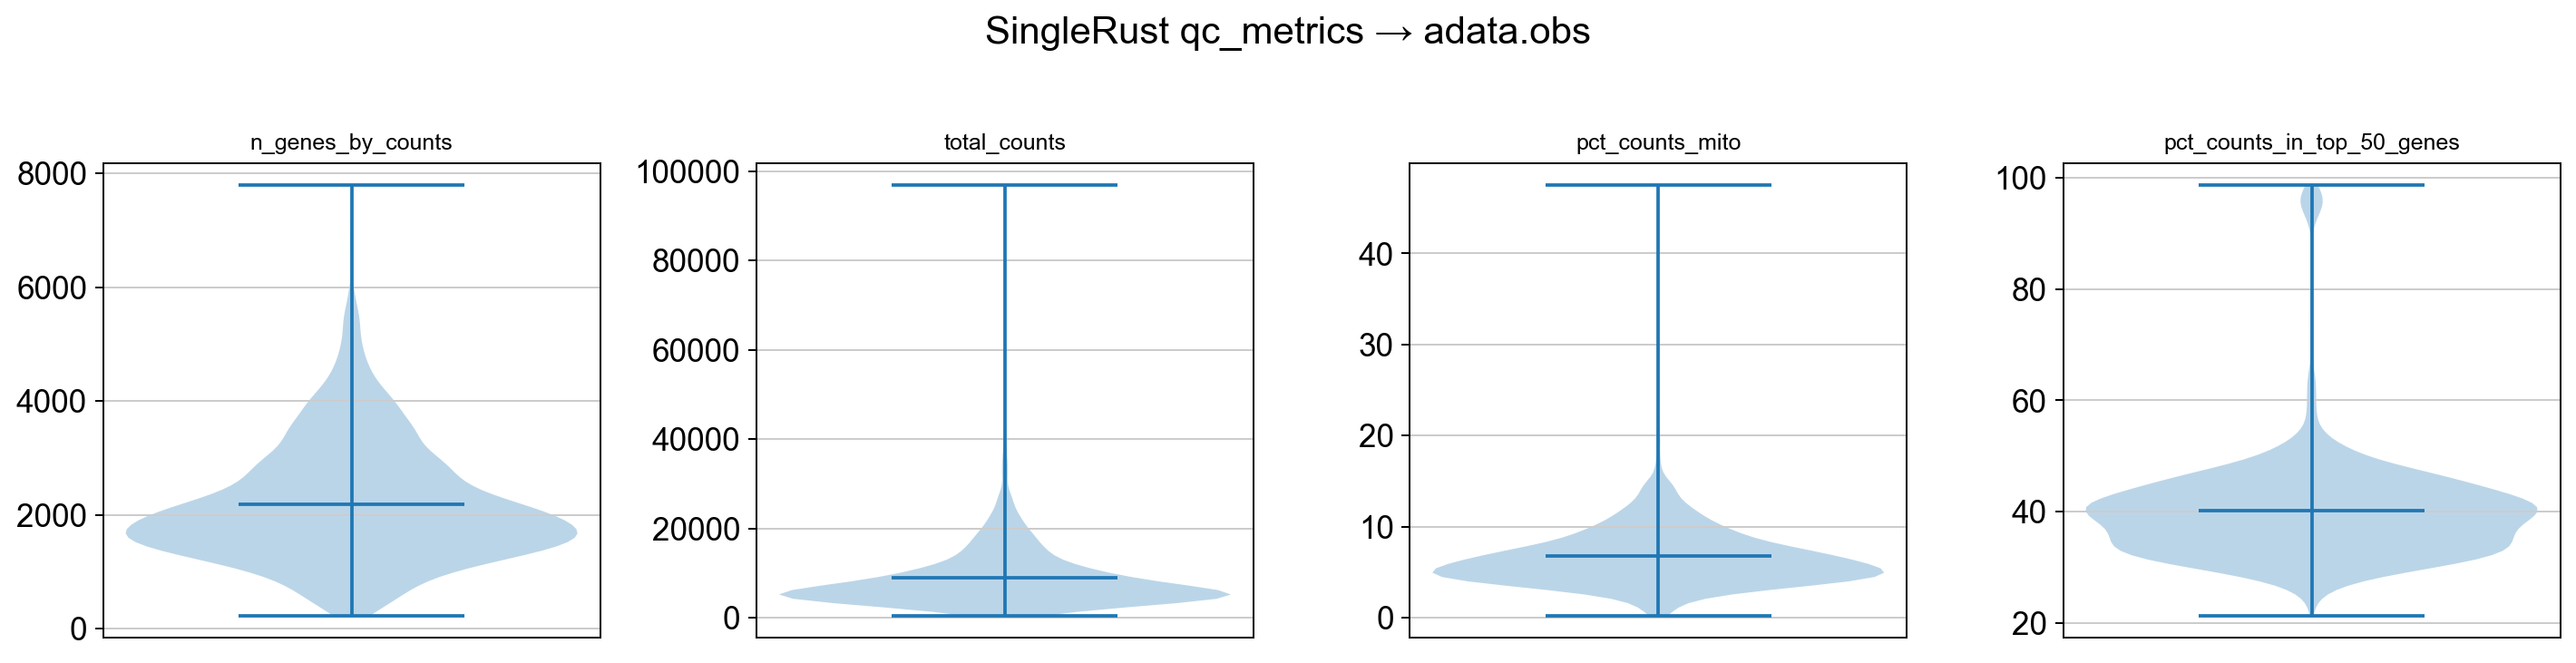

In [5]:
qc = ["n_genes_by_counts","total_counts","pct_counts_mito","pct_counts_in_top_50_genes"]
fig, axes = plt.subplots(1, len(qc), figsize=(4*len(qc), 4))
for ax, k in zip(axes, qc):
    ax.violinplot(adata.obs[k].values, showmeans=True)
    ax.set_title(k, fontsize=10); ax.set_xticks([])
fig.suptitle("SingleRust qc_metrics → adata.obs", y=1.02); plt.tight_layout(); plt.show()

## Step 4 — PCA from SingleRust (`obsm["X_pca"]`, `uns` variance ratios)

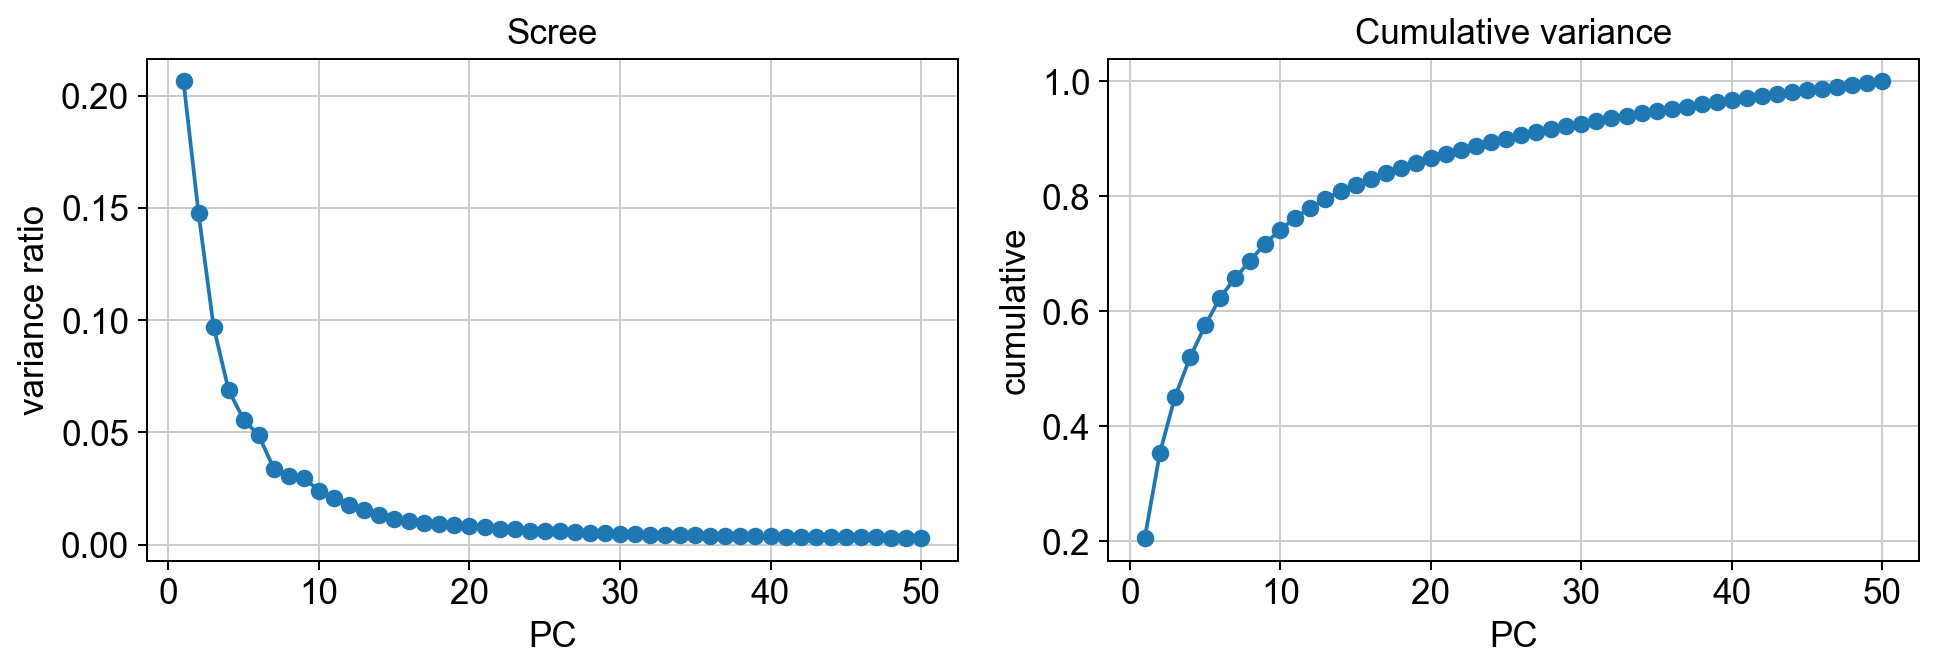

/var/folders/90/w5fv64ld029dplppj_w74xfm0000gn/T/ipykernel_49742/2560577305.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for lin, idx in adata.obs.groupby("lineage").indices.items():


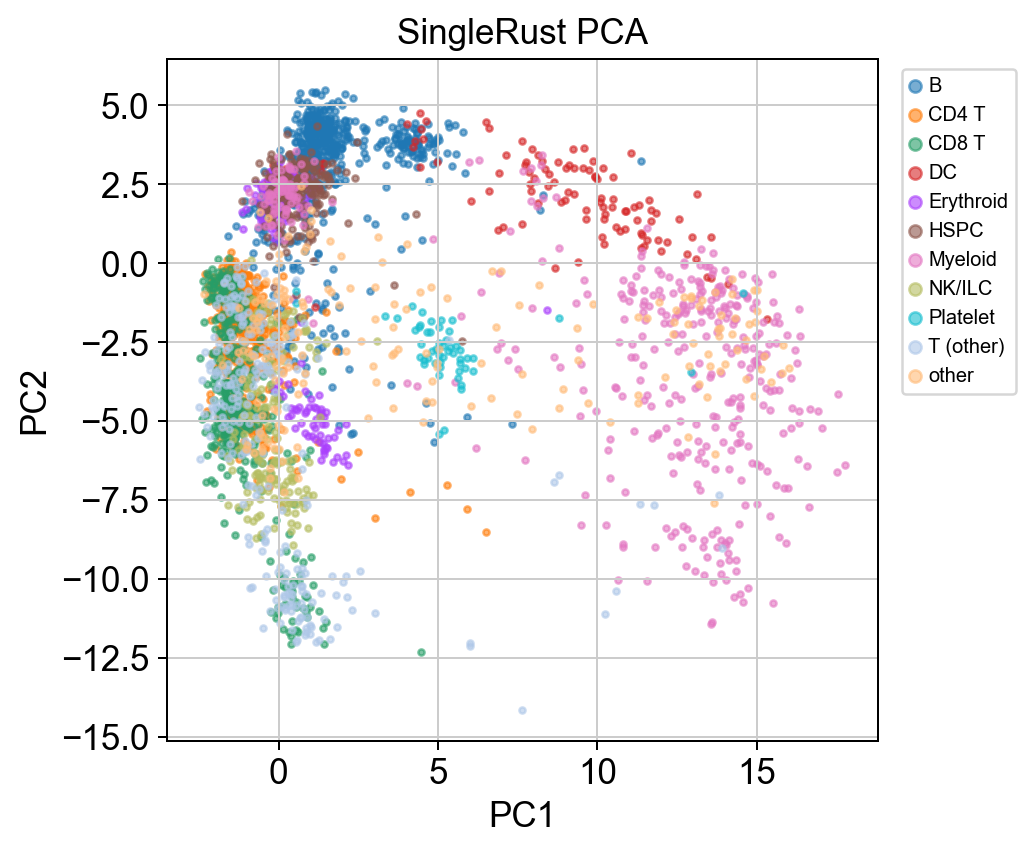

In [6]:
vr = np.asarray(adata.uns["pca_variance_ratio"])
vrc = np.asarray(adata.uns["pca_variance_ratio_cumulative"])
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(np.arange(1,len(vr)+1), vr, "o-"); ax[0].set(xlabel="PC", ylabel="variance ratio", title="Scree")
ax[1].plot(np.arange(1,len(vrc)+1), vrc, "o-"); ax[1].set(xlabel="PC", ylabel="cumulative", title="Cumulative variance")
plt.tight_layout(); plt.show()

# PC1 vs PC2 colored by lineage
X = np.asarray(adata.obsm["X_pca"])
fig, ax = plt.subplots(figsize=(6,5))
for lin, idx in adata.obs.groupby("lineage").indices.items():
    ax.scatter(X[idx,0], X[idx,1], s=6, alpha=.6, label=lin)
ax.set(xlabel="PC1", ylabel="PC2", title="SingleRust PCA")
ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02,1), loc="upper left"); plt.tight_layout(); plt.show()

## Step 5 — Neighbors + UMAP **on SingleRust's embedding**

`use_rep="X_pca"` makes scanpy build the graph from the embedding SingleRust computed — the
handoff that `run_pca_inplace` enables.

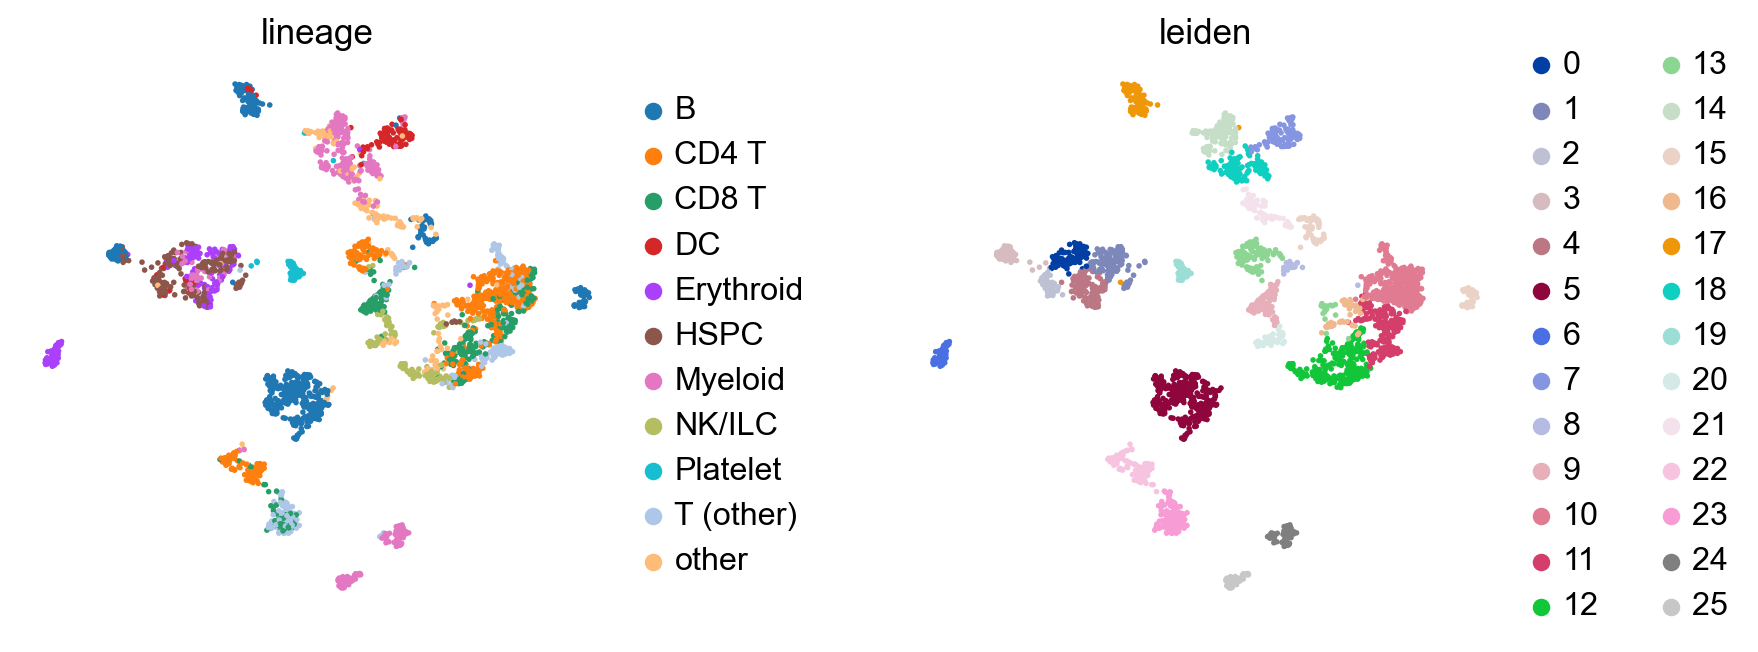

In [7]:
sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=15, random_state=0)
sc.tl.umap(adata, random_state=0)
sc.tl.leiden(adata, resolution=1.0, random_state=0, flavor="igraph", n_iterations=2, directed=False)
sc.pl.umap(adata, color=["lineage","leiden"], wspace=.35, size=20)

## Step 6 — ORA pathway activity (decoupler-style)

`obsm["ora_scores"]` holds `-log10(p)` per cell × marker pathway. Column order is in the
sidecar `output.h5ad.ora_pathways.txt`.

/var/folders/90/w5fv64ld029dplppj_w74xfm0000gn/T/ipykernel_49742/2476033499.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = M.groupby("lineage").mean()


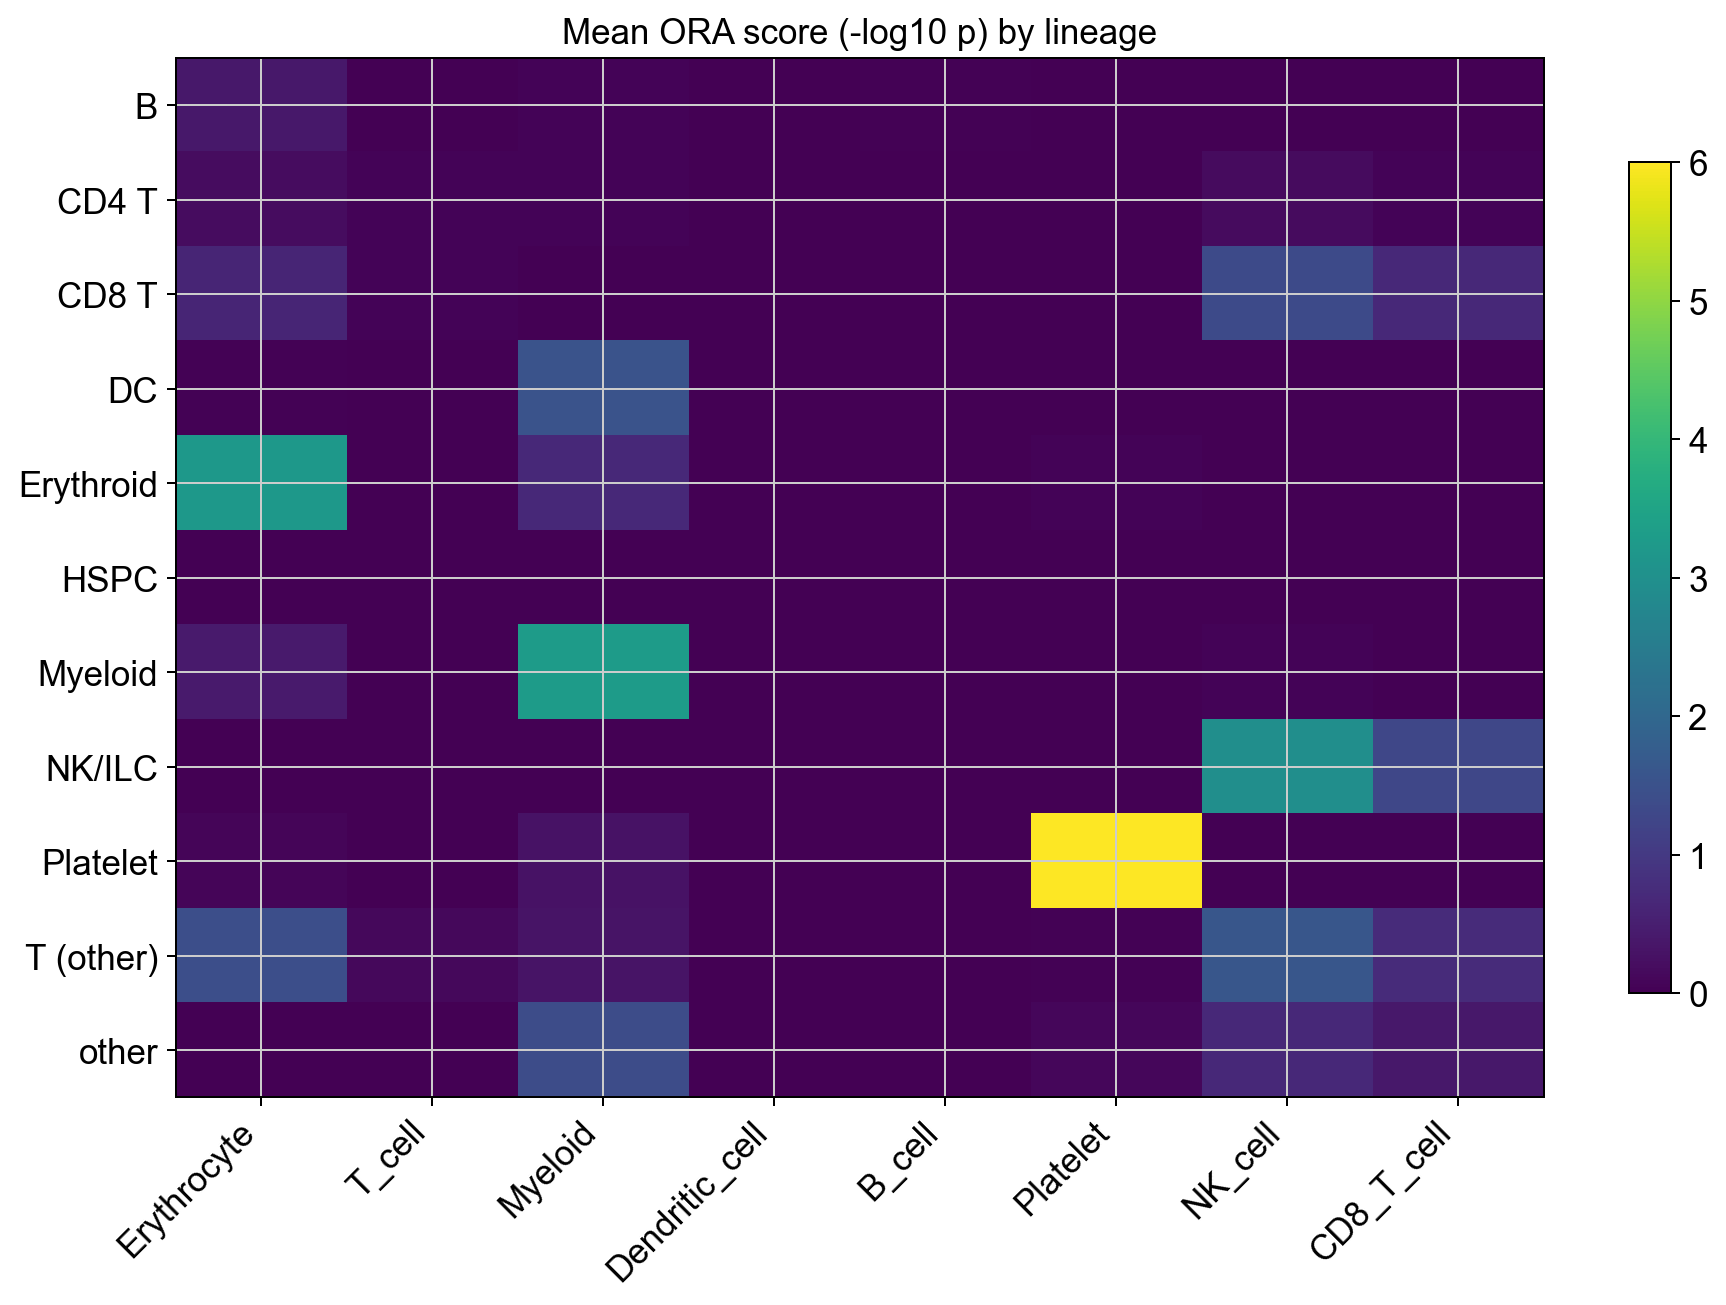

In [8]:
paths = (OUTPUT.parent / (OUTPUT.name + ".ora_pathways.txt")).read_text().split()
ora = pd.DataFrame(np.asarray(adata.obsm["ora_scores"]), columns=paths, index=adata.obs_names)
for p in paths:
    adata.obs[f"ORA:{p}"] = ora[p].values

# Mean ORA score by lineage × pathway (expect a strong diagonal).
M = ora.copy(); M["lineage"] = adata.obs["lineage"].values
heat = M.groupby("lineage").mean()
fig, ax = plt.subplots(figsize=(1.1*len(paths)+2, 0.5*len(heat)+2))
im = ax.imshow(heat.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(paths))); ax.set_xticklabels(paths, rotation=45, ha="right")
ax.set_yticks(range(len(heat))); ax.set_yticklabels(heat.index)
ax.set_title("Mean ORA score (-log10 p) by lineage"); fig.colorbar(im, ax=ax, shrink=.8)
plt.tight_layout(); plt.show()

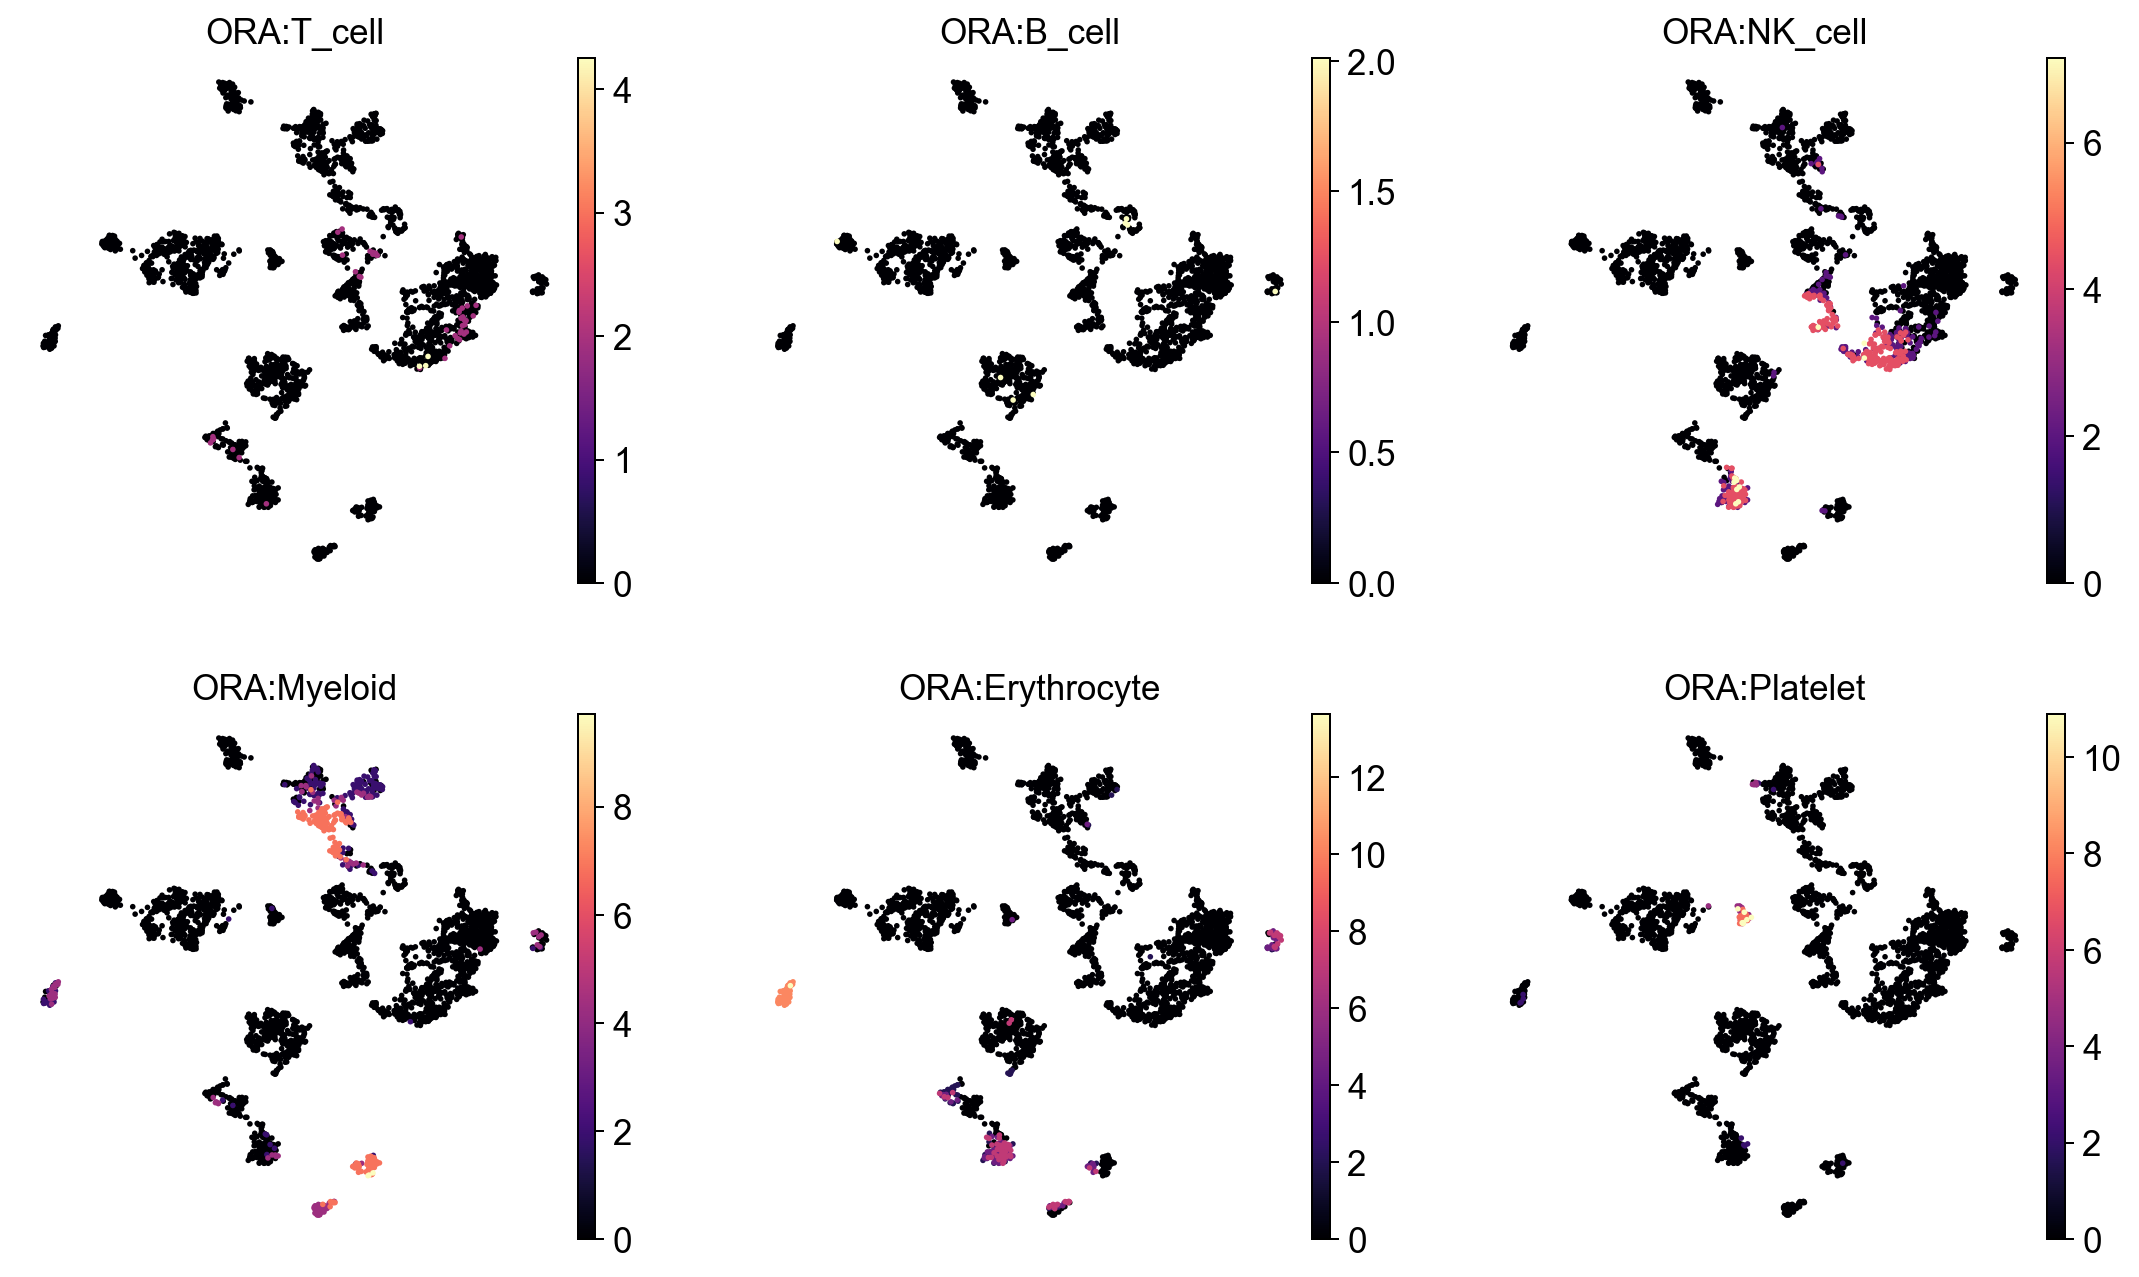

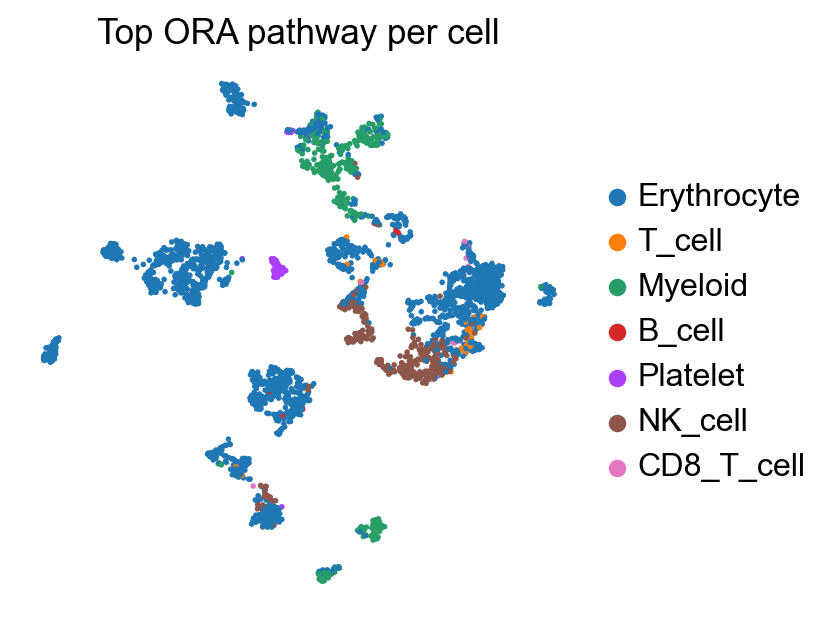

In [9]:
# UMAP colored by a few pathway activities + the argmax pathway per cell.
show = [p for p in ["T_cell","B_cell","NK_cell","Myeloid","Erythrocyte","Platelet"] if p in paths]
sc.pl.umap(adata, color=[f"ORA:{p}" for p in show], ncols=3, cmap="magma", size=20)

adata.obs["ORA_top"] = pd.Categorical(ora.values.argmax(1))
adata.obs["ORA_top"] = adata.obs["ORA_top"].cat.rename_categories({i: paths[i] for i in range(len(paths))})
sc.pl.umap(adata, color="ORA_top", title="Top ORA pathway per cell", size=20)

## Summary

- **`write_h5ad`** round-trips a full AnnData (X, obs/var, obsm, uns) back to scanpy.
- **`run_pca_inplace`** populates `obsm["X_pca"]` + `uns` variance ratios → drives neighbors/UMAP.
- **dense `normalize`/`log1p`** run without panicking.
- **`run_ora`** scores marker pathways per cell, recovering the expected lineage structure.
- **QC fix** (`top_segment_proportions`) lets `qc_metrics` run on real data.

> Note: SingleRust writes blosc/zstd-compressed `.h5ad`, so Python readers must
> `import hdf5plugin` first. (A future `write_h5ad` option for gzip/uncompressed output would
> remove that requirement.)